Cell 1: imports and load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Cell 2: explore

Shape: (150, 4)
Class names: ['setosa', 'versicolor', 'virginica']
Missing values: 0


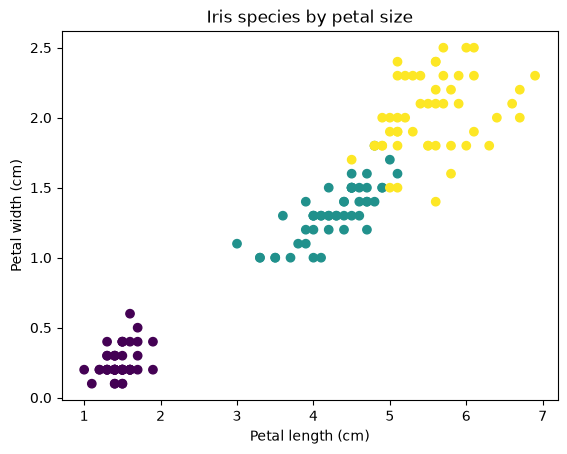

In [2]:
print("Shape:", X.shape)
print("Class names:", [str(c) for c in iris.target_names])
print("Missing values:", X.isnull().sum().sum())

plt.scatter(X["petal length (cm)"], X["petal width (cm)"], c=y)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris species by petal size")
plt.show()

Cell 3: split and train

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{name} accuracy: {accuracy_score(y_test, preds):.2f}")

KNN accuracy: 1.00
Decision Tree accuracy: 0.93


Cell 4: evaluate KNN

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



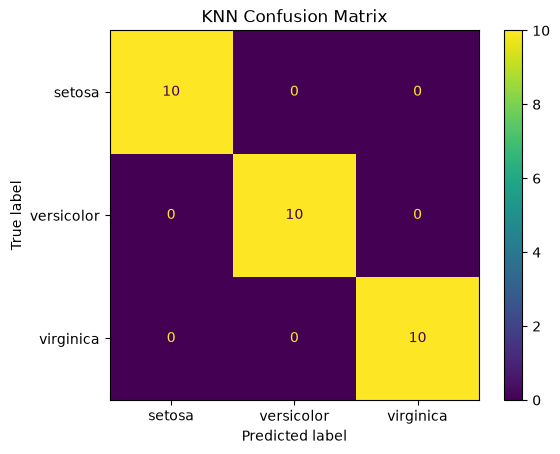

In [4]:
knn = models["KNN"]
print(classification_report(y_test, knn.predict(X_test), target_names=iris.target_names))

ConfusionMatrixDisplay.from_estimator(
    knn, X_test, y_test, display_labels=iris.target_names
)
plt.title("KNN Confusion Matrix")
plt.show()

Cell 5: predict a new flower

In [5]:
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)
prediction = knn.predict(new_flower)[0]
print("Predicted species:", iris.target_names[prediction])

Predicted species: setosa
